<a href="https://colab.research.google.com/github/anushriadapawar/Cafeteria-Load-Prediction/blob/main/Cafeteria_Load_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import nest_asyncio
import asyncio
import json
import websocket

In [2]:
np.random.seed(42)

data_size = 200

temperature = np.random.uniform(15, 40, data_size)
is_rainy = np.random.choice([0, 1], data_size)
is_weekday = np.random.choice([0, 1], data_size)
humidity = np.random.uniform(30, 90, data_size)

# Lunch load logic
lunch_load = (
    120
    + temperature * 3
    - is_rainy * 25
    + is_weekday * 40
    - humidity * 0.5
    + np.random.normal(0, 10, data_size)
)

df = pd.DataFrame({
    "temperature_c": temperature,
    "is_rainy": is_rainy,
    "is_weekday": is_weekday,
    "humidity": humidity,
    "lunch_load": lunch_load.astype(int)
})

df.head()

,temperature_c,is_rainy,is_weekday,humidity,lunch_load
0,24.363503,1,0,36.187432,144
1,38.767858,1,1,84.153174,201
2,33.299849,0,1,60.315142,228
3,29.966462,0,1,79.587448,199
4,18.900466,1,0,49.202976,121


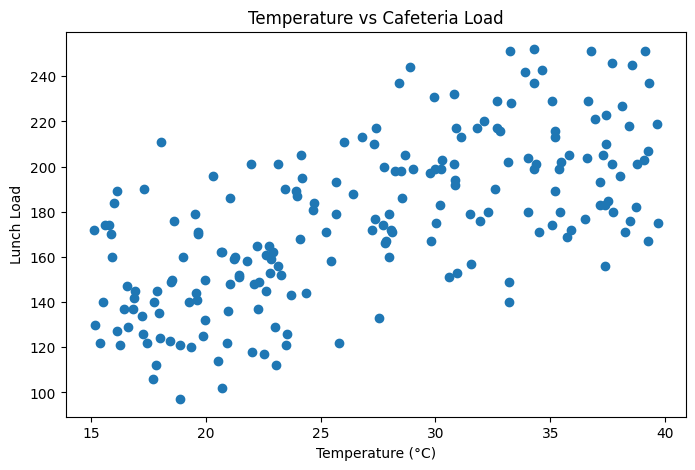

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(df["temperature_c"], df["lunch_load"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Lunch Load")
plt.title("Temperature vs Cafeteria Load")
plt.show()

In [4]:
X = df[["temperature_c", "is_rainy", "is_weekday", "humidity"]]
y = df["lunch_load"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Accuracy (R²):", model.score(X_test, y_test))

Model Accuracy (R²): 0.9324413987688333


In [5]:
def predict_load(temp, rain, weekday, humidity):
    input_data = np.array([[temp, rain, weekday, humidity]])
    return int(model.predict(input_data)[0])

predict_load(32, 0, 1, 55)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


227